<a href="https://colab.research.google.com/github/eugeniatate-duke/XAI-Mechanistic-Interpretability-Shark-Tank/blob/main/MechInterpet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigating a Tiny Switch-Counting Network

Name: Eugenia Tate

## Task
Train a small neural network to count how many times neighboring
bits differ in a six-bit sequence.

Example: 000111 has one switch; 010101 has five switches.

## Research question
Does a hidden neuron respond to a particular neighboring-bit transition?

In [1]:
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# make model initialization repeatable
torch.manual_seed(7)

## Dataset Generation

There are 64 possible six-bit binary sequences.
I will generate all of them and label each with its number of switches.

This experiment studies a model trained on this complete, tiny input
domain. It does not test generalization to unseen sequences.

In [2]:
# generate every possible six-bit sequence
X = torch.tensor(
    list(itertools.product([0, 1], repeat=6)),
    dtype=torch.float32
)

# compare neighboring bits and count how many pairs differ
y = (X[:, 1:] != X[:, :-1]).sum(dim=1, keepdim=True).float()

print("Input shape:", X.shape)
print("Label shape:", y.shape)

# check a few examples
for i in [0, 7, 21, 63]:
    print(X[i].int().tolist(), "->", int(y[i].item()), "switches")

Input shape: torch.Size([64, 6])
Label shape: torch.Size([64, 1])
[0, 0, 0, 0, 0, 0] -> 0 switches
[0, 0, 0, 1, 1, 1] -> 1 switches
[0, 1, 0, 1, 0, 1] -> 5 switches
[1, 1, 1, 1, 1, 1] -> 0 switches


## Model and training

SwitchCountingMLP(
  (fc1): Linear(in_features=6, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)
Final training MSE: 0.0000
Validation MAE: 0.0027
Rounded Accuracy: 1.0


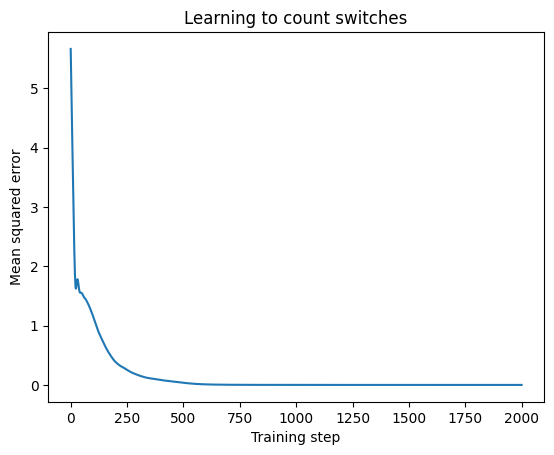

In [4]:
# Updated Model for Regression
class SwitchCountingMLP(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)  # Output is a single scalar

    def forward(self, x):
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h  # for interpretability

# Instantiate model
torch.manual_seed(7)
model = SwitchCountingMLP()
print(model)

# Training loop with MSE loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss() # larger mistakes receive larger penalty

losses = []
model.train()
for epoch in range(2000):
    out, _ = model(X)
    loss = criterion(out, y)

    optimizer.zero_grad() # clear gradients from prev step
    loss.backward()  # calc how each parm affects the loss
    optimizer.step() # update parms to reduce loss
    losses.append(loss.item())

print(f"Final training MSE: {losses[-1]:.4f}")

# Evaluation: Mean Absolute Error + Rounded Accuracy
model.eval()
with torch.no_grad():
    preds, _ = model(X)
    mae = (preds - y).abs().mean().item()
    # rounded_preds = torch.round(preds).squeeze().long()
    accuracy = (preds.round() == y).float().mean().item()

print(f"Training domain MAE: {mae:.4f}") # how far preds are from correct on avg
print(f"Rounded Accuracy: {accuracy:.1f}") # how often rounding pred gives the correct out

# loss surve - ti see if fit improved during training
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("Learning to count switches")
plt.show()

Model learned task well:


*  MAE of 0.0027: predictions differ from the correct switch count by only 0.0027 on average
*   Rounded accuracy of 1.0: all 64 predictions are correct after rounding

*  MSE of 0.0000: the error is small enough to display as zero at four decimal places; it need not be exactly zero
*   Loss curve: error drops sharply, then settles close to zero. The small early bump is normal during optimization





## Hidden-neuron investigation

In [5]:
# Example: this sequence has one switch: between the third and fourth bits.
sample = torch.tensor([[0, 0, 0, 1, 1, 1]], dtype=torch.float32)

model.eval()
with torch.no_grad():
    prediction, activations = model(sample)

print("Input:", sample.int().tolist()[0])
print("True switch count:", 1)
print(f"Predicted switch count: {prediction.item():.4f}")

for neuron, activation in enumerate(activations[0]):
    print(f"Neuron {neuron}: {activation.item():.4f}")

Input: [0, 0, 0, 1, 1, 1]
True switch count: 1
Predicted switch count: 1.0008
Neuron 0: 0.0110
Neuron 1: 0.1778
Neuron 2: 0.3130
Neuron 3: 0.0000
Neuron 4: 0.0000
Neuron 5: 0.1601
Neuron 6: 0.0000
Neuron 7: 0.2209
Neuron 8: 1.1530
Neuron 9: 0.0036


Model predicted 1.0008 which is very close to true count of 1 switches.
Neurons 3,4,6 are inactive for this example input.
Neuron 8 has largest activation for this input.

000111: true=1, predicted=1.001
111000: true=1, predicted=1.002
001101: true=3, predicted=3.003
010101: true=5, predicted=4.993


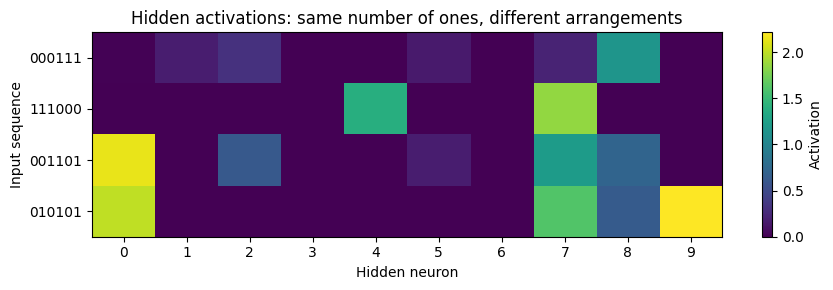

In [6]:
# Same number of ones, different arrangements and switch counts.
examples = torch.tensor([
    [0, 0, 0, 1, 1, 1],  # 1 switch
    [1, 1, 1, 0, 0, 0],  # 1 switch, opposite direction
    [0, 0, 1, 1, 0, 1],  # 3 switches
    [0, 1, 0, 1, 0, 1],  # 5 switches
], dtype=torch.float32)

true_counts = (examples[:, 1:] != examples[:, :-1]).sum(dim=1)

with torch.no_grad():
    predictions, activations = model(examples)

labels = ["000111", "111000", "001101", "010101"]

for i, label in enumerate(labels):
    print(
        f"{label}: true={true_counts[i].item()}, "
        f"predicted={predictions[i].item():.3f}"
    )

plt.figure(figsize=(9, 3))
plt.imshow(activations.numpy(), aspect="auto", cmap="viridis")
plt.xticks(range(10))
plt.yticks(range(4), labels)
plt.xlabel("Hidden neuron")
plt.ylabel("Input sequence")
plt.title("Hidden activations: same number of ones, different arrangements")
plt.colorbar(label="Activation")
plt.tight_layout()
plt.show()

### Initial hypothesis

In the four example inputs, neuron 0 activated strongly for the two
sequences ending in 01. Hypothesis is that Neuron 0 responds more strongly when the final two bits form a 0-to-1 transition.

An alternative explanation is that it responds to higher total switch count.
I will compare its activations across all 64 inputs, grouped by their
final two bits.

Below i explore groups containing 16 possible combinations of the first four bits and compare the endings.

Ending 00: n=16, mean=0.527, min=0.000, max=1.112
Ending 01: n=16, mean=1.537, min=0.937, max=2.137
Ending 10: n=16, mean=0.000, min=0.000, max=0.000
Ending 11: n=16, mean=0.014, min=0.000, max=0.086


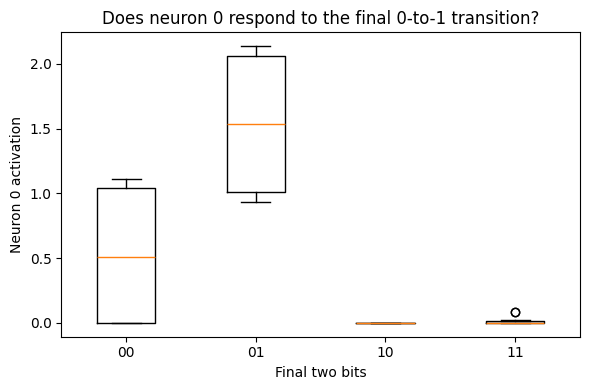

In [7]:
neuron = 0
pair_labels = ["00", "01", "10", "11"]
groups = []

with torch.no_grad():
    _, all_activations = model(X)

for pair in pair_labels:
    # Select every input with this final pair.
    mask = (
        (X[:, -2] == int(pair[0])) &
        (X[:, -1] == int(pair[1]))
    )

    values = all_activations[mask, neuron]
    groups.append(values.numpy())

    print(
        f"Ending {pair}: n={len(values)}, "
        f"mean={values.mean().item():.3f}, "
        f"min={values.min().item():.3f}, "
        f"max={values.max().item():.3f}"
    )

plt.figure(figsize=(6, 4))
plt.boxplot(groups)
plt.xticks([1, 2, 3, 4], pair_labels)
plt.xlabel("Final two bits")
plt.ylabel("Neuron 0 activation")
plt.title("Does neuron 0 respond to the final 0-to-1 transition?")
plt.tight_layout()
plt.show()

The results above support the hypothesis:
- 01 has the highest mean activation of 1.537, and all 16 examples activate neuron 0
- 00 also activates Neuron 0 in some cases, reaching 1.112
- 10 produces zero activation throughout for neuron 0
- 11 produces almost zero activation for neuron 0

In [9]:
# Match inputs with identical first four bits.
ending_00 = (X[:, -2] == 0) & (X[:, -1] == 0)
ending_01 = (X[:, -2] == 0) & (X[:, -1] == 1)

# Our dataset's ordering aligns the same prefixes in these groups.
assert torch.equal(X[ending_00, :4], X[ending_01, :4])

with torch.no_grad():
    _, h = model(X)

difference = h[ending_01, 0] - h[ending_00, 0]

print(f"Smallest activation increase: {difference.min().item():.4f}")
print(f"Largest activation increase: {difference.max().item():.4f}")
print(f"Pairs with increased activation: {(difference > 0).sum().item()}/16")

Smallest activation increase: 0.9370
Largest activation increase: 1.0245
Pairs with increased activation: 16/16


When changing an input from prefix00 to prefix01, neuron 0’s activation always increases—by 0.9370 to 1.0245

This strengthens the hypothesis: the higher average activation for ending in 01 was not caused by comparing different earlier-bit patterns - Neuron preferentially responds to inouts ending in 01, but its response also depends on earlier bits so it is not entirely exclusive to just ending two bits.

## Ablation experiment

In [8]:
neuron = 0

model.eval()
with torch.no_grad():
    # Original predictions and hidden activations.
    original_predictions, h = model(X)

    # Remove neuron 0's activation while preserving the others.
    h_ablated = h.clone()
    h_ablated[:, neuron] = 0 # set the copy activation to zero

    # pass altered activations through fc2
    # recalculate predictions using the altered hidden layer w/o neuron 0 contribution
    ablated_predictions = model.fc2(h_ablated)

    original_mae = (original_predictions - y).abs().mean().item()
    ablated_mae = (ablated_predictions - y).abs().mean().item()

    change = (ablated_predictions - original_predictions).squeeze(1)

print(f"Original MAE: {original_mae:.4f}")
print(f"Ablated MAE: {ablated_mae:.4f}")
print(f"Neuron 0 output weight: {model.fc2.weight[0, neuron].item():.4f}")

for pair in ["00", "01", "10", "11"]:
    mask = (
        (X[:, -2] == int(pair[0])) &
        (X[:, -1] == int(pair[1]))
    )
    print(f"Ending {pair}: mean prediction change = {change[mask].mean().item():+.4f}")

Original MAE: 0.0027
Ablated MAE: 0.5984
Neuron 0 output weight: 1.1487
Ending 00: mean prediction change = -0.6059
Ending 01: mean prediction change = -1.7656
Ending 10: mean prediction change = +0.0000
Ending 11: mean prediction change = -0.0164


Neuron 0 substiantially contributed to model's predictions, especially those ending in 01.
Removing it increases overall MAE from 0.0027 to 0.5984 hence we can see trained model depends on its contribution to maintain accurate predictions.

However, neuron 0 also contributes to some inputs ending in 00, so it is not an exclusive 01 detector.

## Findings and limitation


Neuron 0 preferentially responds to inputs ending in `01`. Its mean activation was 1.537 for this ending, compared with 0.527 for `00`, zero for `10`, and 0.014 for `11`. Changing the ending from `00` to `01`, while keeping the first four bits fixed, increased its activation in all 16 matched pairs.

Neuron 0 also contributes positively to the predicted switch count. Zeroing its activation increased overall MAE from 0.0027 to 0.5984. Predictions for inputs ending in `01` decreased by 1.7656 on average.

The neuron is not an exclusive `01` detector: some inputs ending in `00` also activate it, and earlier bits influence its response. These findings describe this particular trained model over the 64 six-bit inputs; they do not establish the same mechanism across other training seeds.